In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.io as pio
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
import webbrowser
import os

In [2]:
nltk.download('vader_lexicon')    

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [3]:
apps_df=pd.read_csv('googleplaystore.csv')
reviews_df=pd.read_csv('user reviews.csv')

In [4]:
apps_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [5]:
reviews_df.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [6]:
# pd.read_csv() : csv files
# pd.read_excel() : excel files
# pd.read_sql() : sql files
# pd.read_json() : json files

In [7]:
# df.isnull() : Missing values
# df.dropna() : Removes rows and columns that contain the missing values
# df.fillna() : Fills missing values

In [8]:
# df.duplicated() : identifies duplicates
# df.drop_duplicates : Removes duplicate rows

In [9]:
# step 2 : Data cleaning
apps_df = apps_df.dropna(subset=['Rating'])
for column in apps_df.columns :
    apps_df[column].fillna(apps_df[column].mode()[0],inplace=True)
apps_df.drop_duplicates(inplace=True)
apps_df=apps_df=apps_df[apps_df['Rating']<=5]
reviews_df.dropna(subset=['Translated_Review'],inplace=True)

In [10]:
# convert the  Istalls columns to numeric by removing commas and +
apps_df['Installs']=apps_df['Installs'].str.replace(',','').str.replace('+','').astype(int)
# Convert price column to numeric ofter removing $
apps_df['Price']=apps_df['Price'].str.replace('$','').astype(float)

In [11]:
apps_df.dtypes

App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs            int64
Type               object
Price             float64
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

In [12]:
merged_df=pd.merge(apps_df,reviews_df,on='App',how='inner')

In [13]:
merged_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,A kid's excessive ads. The types ads allowed a...,Negative,-0.250,1.000000
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,It bad >:(,Negative,-0.725,0.833333
2,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,like,Neutral,0.000,0.000000
3,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,I love colors inspyering,Positive,0.500,0.600000
4,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,I hate,Negative,-0.800,0.900000


In [14]:
# Data Transfromation
# apps_df['Reviews']=apps_df['Reviews'].astype(int)

In [15]:
def convert_size(size):
    if 'M' in size:
        return float(size.replace('M',''))
    elif 'k' in size:
        return float(size.replace('k',''))/1024
    else:
        return np.nan
apps_df['Size']=apps_df['Size'].apply(convert_size)        

In [16]:
apps_df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10834,FR Calculator,FAMILY,4.0,7,2.6,500,Free,0.0,Everyone,Education,"June 18, 2017",1.0.0,4.1 and up
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53.0,5000,Free,0.0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6,100,Free,0.0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,NaN,1000,Free,0.0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [17]:
# Lograrithmic
apps_df['Log_Installs']=np.log(apps_df['Installs'])

In [18]:
apps_df['Reviews']=apps_df['Reviews'].astype(int)

In [19]:
apps_df['Log_Reviews']=np.log(apps_df['Reviews'])

In [20]:
apps_df.dtypes

App                object
Category           object
Rating            float64
Reviews             int64
Size              float64
Installs            int64
Type               object
Price             float64
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
Log_Installs      float64
Log_Reviews       float64
dtype: object

In [21]:
def rating_group(rating):
    if rating >=4:
        return 'TOP rated app'
    elif rating >=3:
        return 'Above average'
    elif rating >=2:
        return 'Average'
    else:
        return 'Below Average'
apps_df['Rating_Group']=apps_df['Rating'].apply(rating_group)        

In [22]:
# Revenue column
apps_df['Revenue']=apps_df['Price']*apps_df['Installs']

In [23]:
sia = SentimentIntensityAnalyzer()

In [24]:
# polarity Scores in SIA
# positive , Negative , Neutral and compound : -1 -very negative ; +1 - very positive

In [25]:
review = "This app is amazing! I love the new features."
sentiment_score= sia.polarity_scores(review)
print(sentiment_score)

{'neg': 0.0, 'neu': 0.42, 'pos': 0.58, 'compound': 0.8516}


In [26]:
review = "This app is very bad! I hate the new features."
sentiment_score= sia.polarity_scores(review)
print(sentiment_score)

{'neg': 0.535, 'neu': 0.465, 'pos': 0.0, 'compound': -0.8427}


In [27]:
review = "This app is okay."
sentiment_score= sia.polarity_scores(review)
print(sentiment_score)

{'neg': 0.0, 'neu': 0.612, 'pos': 0.388, 'compound': 0.2263}


In [28]:
reviews_df['sentiment_score']=reviews_df['Translated_Review'].apply(lambda x:sia.polarity_scores(str(x))['compound'])

In [29]:
reviews_df.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity,sentiment_score
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333,0.9531
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462,0.6597
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000,0.6249
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000,0.6369
5,10 Best Foods for You,Best way,Positive,1.00,0.300000,0.6369


In [30]:
apps_df['Last Updated']=pd.to_datetime(apps_df['Last Updated'],errors='coerce')

In [31]:
apps_df['Year']=apps_df['Last Updated'].dt.year

In [32]:
apps_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Log_Installs,Log_Reviews,Rating_Group,Revenue,Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,9.210340,5.068904,TOP rated app,0.0,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,13.122363,6.874198,Above average,0.0,2018
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,15.424948,11.379508,TOP rated app,0.0,2018
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,17.727534,12.281384,TOP rated app,0.0,2018
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,11.512925,6.874198,TOP rated app,0.0,2018


In [33]:
html_files_path="./"
if not os.path.exists(html_files_path):
    os.makedirs(html_files_path)

In [34]:
plot_containers = ""

In [35]:
# Save each Plotly figure to an HTML file

def save_plot_as_html(fig, filename, insight):
    global plot_containers
    filepath= os.path.join(html_files_path, filename)
    html_content = pio.to_html(fig, full_html=False, include_plotlyjs='inline')
    # Append the plot and its insight to plot_containers
    plot_containers += f"""
    <div class="plot-container" id="{filename}" onclick="openPlot('{filename}')">
    <div class="plot">{html_content}</div>
    <div class="insights">{insight}</div>
    </div>
    """
    fig.write_html(filepath, full_html=False, include_plotlyjs='inline')

In [36]:
plot_width=400
plot_height=300
plot_bg_color='black'
text_color= 'white'
title_font={'size':16}
axis_font={'size':12}

In [37]:
# Figure 1
category_counts = apps_df['Category'].value_counts().nlargest(10)

fig1 = px.bar(
    x=category_counts.index,
    y=category_counts.values,
    labels={'x': 'Category', 'y': 'Count'},
    title='Top Categories on Play Store',
    color=category_counts.index,
    color_discrete_sequence=px.colors.sequential.Plasma,
    width=400,
    height=300
)
fig1.update_layout(
    plot_bgcolor='black',
    paper_bgcolor='black',
    font_color='white',
    title_font={'size': 16},
    xaxis=dict(title_font={'size': 12}),
    yaxis=dict(title_font={'size': 12}),
    margin=dict(l=10, r=10, t=30, b=10)
)
# fig1.update_traces(marker=dict(pattern=dict(line=dict(color='white', width=1))))
save_plot_as_html(
    fig1,
    "Category Graph 1.html",
    "The top categories on the Play Store are dominated by tools, entertainment, and productivity apps"
)

In [38]:
import pytz
from datetime import datetime

In [39]:
review_subj = reviews_df.groupby('App')['Sentiment_Subjectivity'].mean().reset_index()
bubble_df = apps_df.merge(review_subj, on='App', how='inner')

In [40]:
target_categories = ['GAME', 'BEAUTY', 'BUSINESS', 'COMICS', 'COMMUNICATION',
                      'DATING', 'ENTERTAINMENT', 'SOCIAL', 'EVENTS']

bubble_df = bubble_df[
    (bubble_df['Rating'] > 3.5) &
    (bubble_df['Category'].isin(target_categories)) &
    (bubble_df['Reviews'] > 500) &
    (~bubble_df['App'].str.contains('S', case=False, na=False)) &
    (bubble_df['Sentiment_Subjectivity'] > 0.5) &
    (bubble_df['Installs'] > 50000)
]

In [41]:
category_translation = {
    'BEAUTY': 'सौंदर्य',       # Hindi
    'BUSINESS': 'வணிகம்',      # Tamil
    'DATING': 'Partnersuche'   # German
}
bubble_df['Category_Display'] = bubble_df['Category'].replace(category_translation)

palette = px.colors.qualitative.Bold
color_map = {}
idx = 0
for cat in bubble_df['Category_Display'].unique():
    if cat == 'GAME':
        color_map[cat] = 'pink'
    else:
        color_map[cat] = palette[idx % len(palette)]
        idx += 1

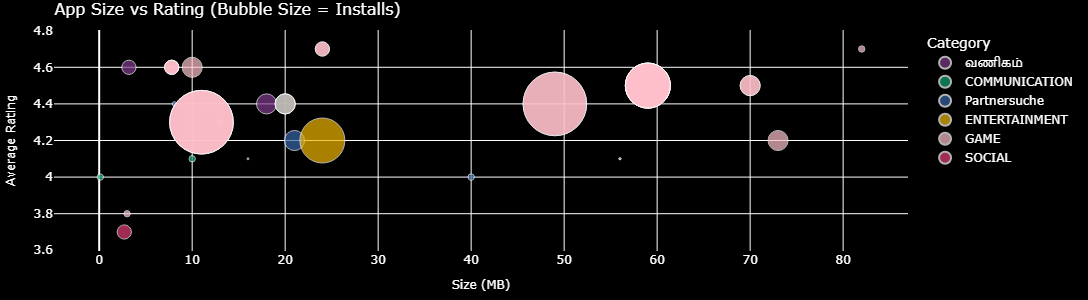

In [42]:
fig2 = px.scatter(
    bubble_df,
    x='Size',
    y='Rating',
    size='Installs',
    color='Category_Display',
    color_discrete_map=color_map,
    hover_name='App',
    size_max=45,
    title='App Size vs Rating (Bubble Size = Installs)',
    labels={'Size': 'Size (MB)', 'Rating': 'Average Rating', 'Category_Display': 'Category'},
    width=plot_width,
    height=plot_height
)
fig2.update_layout(
    plot_bgcolor=plot_bg_color,
    paper_bgcolor=plot_bg_color,
    font_color=text_color,
    title_font=title_font,
    xaxis=dict(title_font=axis_font),
    yaxis=dict(title_font=axis_font),
    margin=dict(l=10, r=10, t=30, b=10)
)

ist = pytz.timezone('Asia/Kolkata')
current_hour = datetime.now(ist).hour

if 17 <= current_hour < 19:
    save_plot_as_html(
        fig2,
        "Bubble Chart - Size vs Rating vs Installs.html",
        "Size vs Rating bubble chart (bubble = Installs), visible only 5 PM-7 PM IST."
    )
    fig2.show()
else:
    print(f"Current IST hour is {current_hour}:00 - bubble chart is hidden "
          f"(only shown on the dashboard between 5 PM and 7 PM IST).")